# Customer Churn Prediction

## Overview

Customer churn refers to a situation where a customer stops using a company's products or services. Predicting customer churn is important because it allows organizations to identify customers who are likely to leave and take proactive steps to retain them.

In this project, a machine learning classification model is developed to predict whether a customer will churn based on demographic, account, and service-related information.

The project includes data exploration, preprocessing, exploratory data analysis, classification model development, model evaluation, hyperparameter tuning, and prediction on new customer data.

## Problem Statement

The objective of this project is to develop a machine learning classification model that predicts whether a customer is likely to churn.

The dataset contains customer demographic information, account details, tenure, and information about the services used by customers.

The target variable is `Churn`, which indicates whether a customer has discontinued the service.

The project aims to:

- Understand the customer dataset.
- Perform exploratory data analysis.
- Handle missing and inconsistent values.
- Encode categorical variables.
- Split the dataset into training and testing sets.
- Develop classification models.
- Evaluate the models using accuracy, precision, recall, and F1-score.
- Tune the selected model.
- Predict churn for new customer data.
- Identify useful business insights from the model.

## Dataset Description

The dataset contains information about customers and the services they use.

### Important Features

- `customerID` – Unique identifier of the customer.
- `gender` – Gender of the customer.
- `SeniorCitizen` – Indicates whether the customer is a senior citizen.
- `Partner` – Indicates whether the customer has a partner.
- `Dependents` – Indicates whether the customer has dependents.
- `tenure` – Number of months the customer has stayed with the company.
- `PhoneService` – Indicates whether the customer has phone service.
- `MultipleLines` – Information about multiple phone lines.
- `InternetService` – Type of internet service.
- `OnlineSecurity` – Indicates whether online security is subscribed.
- `OnlineBackup` – Indicates whether online backup is subscribed.
- `DeviceProtection` – Indicates whether device protection is subscribed.
- `TechSupport` – Indicates whether technical support is subscribed.
- `StreamingTV` – Indicates whether the customer uses streaming TV.
- `StreamingMovies` – Indicates whether the customer uses streaming movies.
- `Contract` – Contract type of the customer.
- `PaperlessBilling` – Indicates whether paperless billing is enabled.
- `PaymentMethod` – Payment method used by the customer.
- `MonthlyCharges` – Monthly amount charged to the customer.
- `TotalCharges` – Total amount charged to the customer.
- `Churn` – Target variable indicating whether the customer churned.

## Import Libraries

The following Python libraries are used for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

The dataset is stored in Google Sheets. It is loaded into a Pandas DataFrame using the CSV export option.

In [2]:
url = "https://docs.google.com/spreadsheets/d/1J2aMbLrRnk8g0Y5TSbz-en_7UxlI7xh0cLIZnIy4aew/export?format=csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

The dataset is examined to understand its structure, dimensions, data types, statistical properties, missing values, and duplicate records.

In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Checking Missing Values

Missing values can affect the performance of machine learning models. Therefore, the dataset is checked for missing values before model development.

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Checking Duplicate Records

Duplicate records can affect the analysis and may cause the model to learn repeated observations. Therefore, duplicate records are checked.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

## Data Preprocessing

Data preprocessing is performed to make the dataset suitable for machine learning.

The preprocessing steps include:

- Removing the customer identifier.
- Converting numerical columns into appropriate numerical data types.
- Handling missing values.
- Encoding categorical variables.
- Separating features and target.

In [11]:
df = df.drop("customerID", axis=1)

In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [13]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

## Encoding the Target Variable

The target variable `Churn` contains categorical values such as `Yes` and `No`.

For classification, these values are converted into numerical values:

- `Yes` -> 1
- `No` -> 0

In [15]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [16]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of customers and identify relationships between customer characteristics and churn.

Visualizations are used to identify patterns that may help explain customer churn.

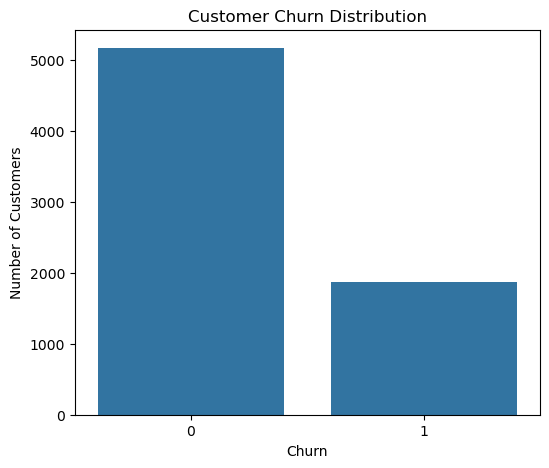

In [17]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The churn distribution shows the number of customers who stayed with the company compared with customers who left the company.

The class distribution should be considered while evaluating the classification model because an imbalanced target can make accuracy alone misleading.

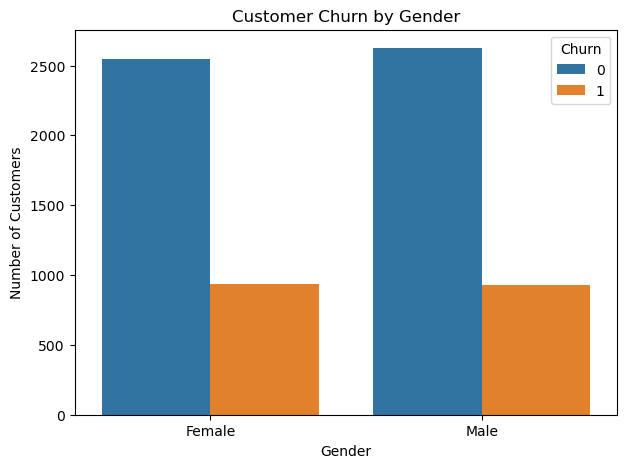

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

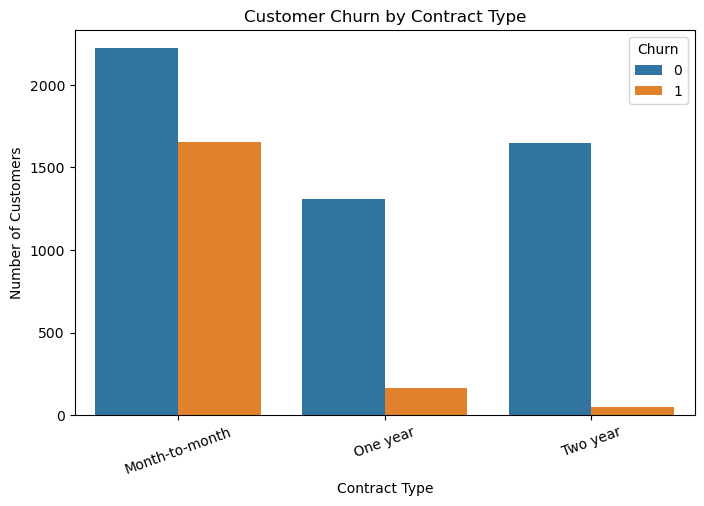

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

The churn rate can vary across different contract types. Customers with shorter-term contracts may have different churn behavior compared with customers who have longer-term contracts.

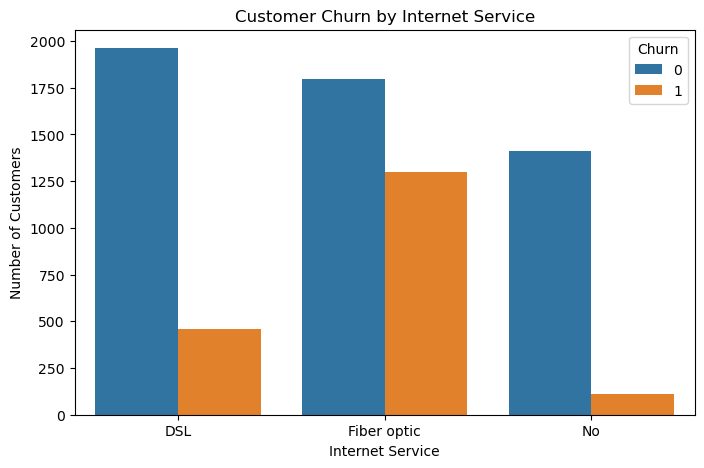

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

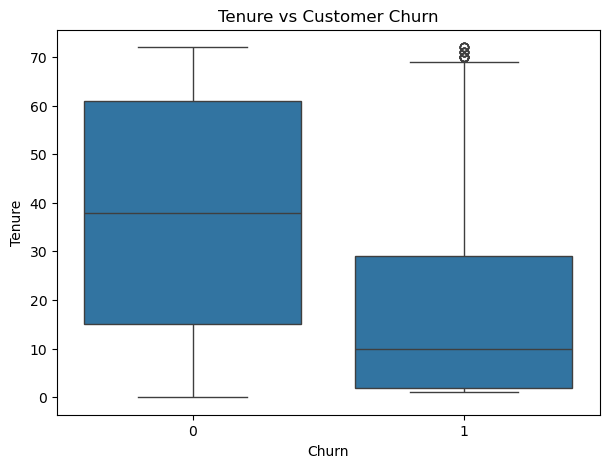

In [21]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

### Observation

Tenure represents the number of months a customer has remained with the company.

The distribution of tenure between churned and non-churned customers can help determine whether customer loyalty or length of service is related to churn.

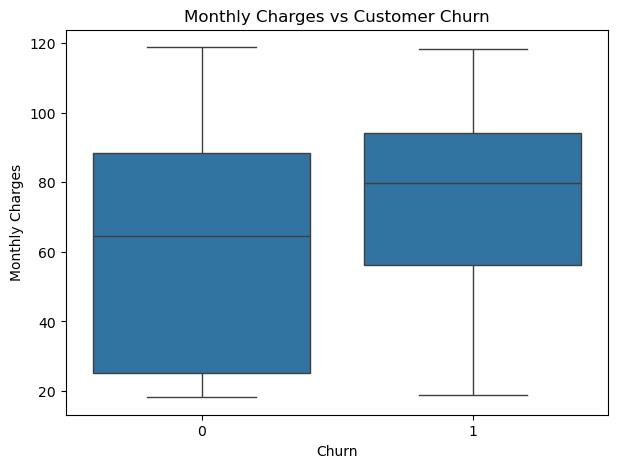

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Feature and Target Separation

The target variable is `Churn`.

All remaining relevant variables are used as input features.

In [23]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical dummy variables using one-hot encoding.

The `drop_first=True` parameter is used to avoid unnecessary duplicate information among dummy variables.

In [24]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [25]:
X = X.astype(float)

In [26]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Train-Test Split

The dataset is divided into training and testing sets.

80% of the data is used for training the models and 20% is used for evaluating their performance on unseen data.

Stratification is used to maintain the proportion of churn and non-churn customers in both datasets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


## Feature Scaling

Standardization is applied to the features before training Logistic Regression.

The training data is used to fit the scaler, while the testing data is only transformed. This prevents information from the test dataset from influencing the training process.

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

Logistic Regression is a classification algorithm used to predict the probability of a binary outcome.

In this project, it is used to predict whether a customer will churn or not.

In [30]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
log_pred = log_model.predict(X_test_scaled)

In [32]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Logistic Regression
-------------------
Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1 Score : 0.6091954022988506


In [33]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



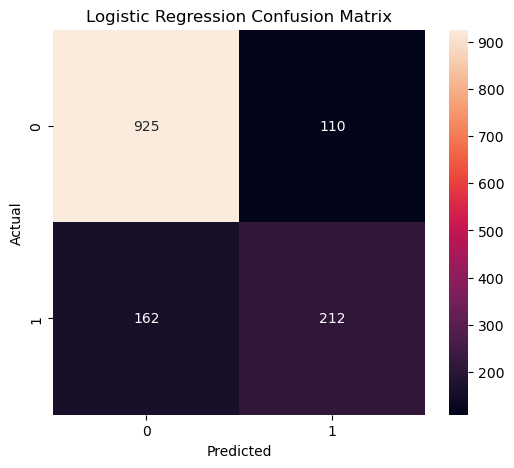

In [34]:
cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows how many customers were correctly and incorrectly classified.

- True Negative: Correctly predicted non-churn customers.
- True Positive: Correctly predicted churn customers.
- False Positive: Customers predicted as churn but who did not churn.
- False Negative: Customers predicted as non-churn but who actually churned.

False negatives are particularly important in customer churn prediction because failing to identify a customer who is likely to churn may result in a lost opportunity for customer retention.

## Decision Tree Classifier

A Decision Tree is a classification algorithm that makes predictions by splitting the dataset based on feature values.

It is useful because the resulting decisions can be relatively easy to interpret.

In [35]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(X_test)

In [36]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree")
print("-------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree
-------------
Accuracy : 0.7416607523066004
Precision: 0.5138888888888888
Recall   : 0.4946524064171123
F1 Score : 0.5040871934604905


## Random Forest Classifier

Random Forest is an ensemble classification algorithm that combines multiple decision trees to improve prediction performance and reduce the risk of relying on a single tree.

It is used to compare its performance with Logistic Regression and Decision Tree.

In [37]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [38]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------
Accuracy : 0.7863733144073811
Precision: 0.6237288135593221
Recall   : 0.4919786096256685
F1 Score : 0.5500747384155455


## Model Comparison

The performance of the classification models is compared using accuracy, precision, recall, and F1-score.

F1-score is especially useful because it considers both precision and recall.

In [39]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        log_f1,
        dt_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.741661,0.513889,0.494652,0.504087
2,Random Forest,0.786373,0.623729,0.491979,0.550075


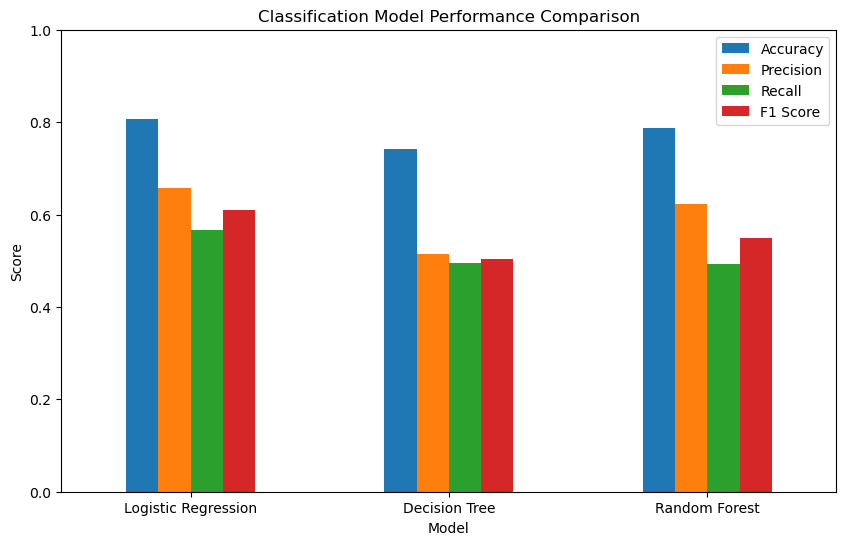

In [40]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

## Hyperparameter Tuning

Hyperparameter tuning is performed to identify better parameter combinations for the Random Forest classifier.

GridSearchCV evaluates different combinations using cross-validation and selects the combination that provides the best F1-score.

In [41]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [42]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [43]:
print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Cross-Validation F1 Score:
0.5720381666596854


## Final Model

The best Random Forest model obtained through hyperparameter tuning is selected as the final model.

The final model is evaluated on the unseen test dataset to determine its generalization performance.

In [44]:
best_model = grid_search.best_estimator_

final_pred = best_model.predict(X_test)

In [45]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("Final Model Performance")
print("-----------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

Final Model Performance
-----------------------
Accuracy : 0.8034066713981547
Precision: 0.6611295681063123
Recall   : 0.5320855614973262
F1 Score : 0.5896296296296296


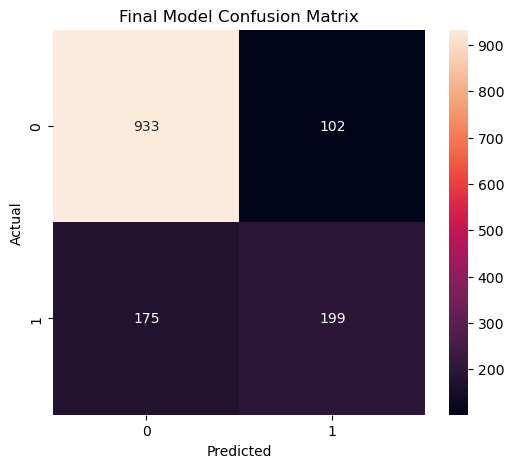

In [46]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d"
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

The feature importance values from the Random Forest model are analyzed to identify the features that contribute most to customer churn prediction.

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.192110
3,TotalCharges,0.156355
2,MonthlyCharges,0.114689
10,InternetService_Fiber optic,0.069904
28,PaymentMethod_Electronic check,0.060507
25,Contract_Two year,0.058757
13,OnlineSecurity_Yes,0.040883
24,Contract_One year,0.033061
19,TechSupport_Yes,0.025254
26,PaperlessBilling_Yes,0.022812


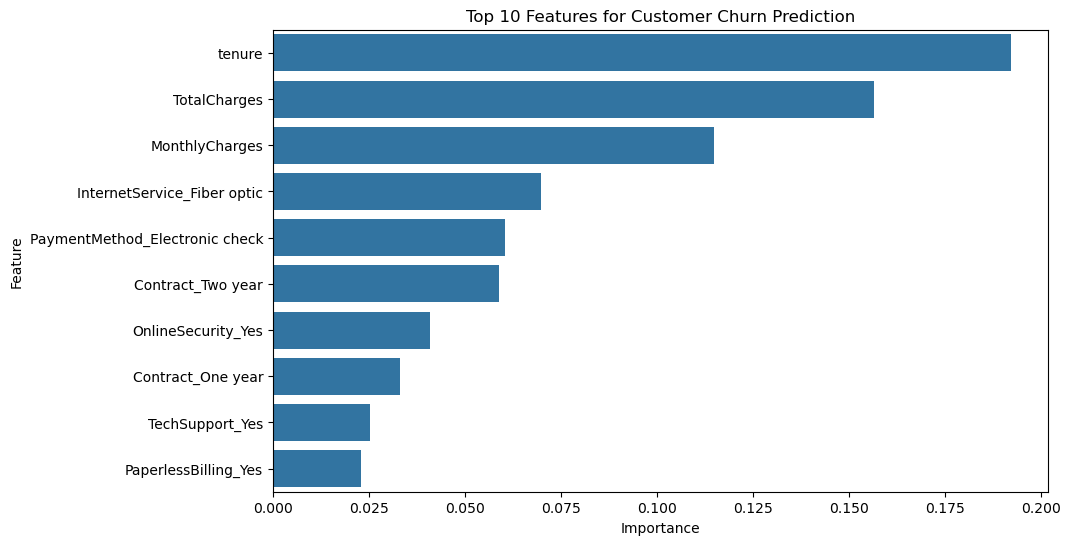

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Features for Customer Churn Prediction")

plt.show()

## Prediction on New Customer Data

The final trained model can be used to predict whether a new customer is likely to churn.

The new customer's features must undergo the same preprocessing and feature encoding used during model training.

In [49]:
print("Number of features:", len(X.columns))
print(X.columns.tolist())

Number of features: 30
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [50]:

new_customer = X_test.iloc[[0]]

new_customer_prediction = best_model.predict(new_customer)

print("Prediction:", new_customer_prediction)

Prediction: [0]


In [51]:
if new_customer_prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

The customer is likely to stay.


In [52]:
new_customer = X_test.iloc[[0]]

new_customer_prediction = best_model.predict(new_customer)

print("Prediction:", new_customer_prediction)

if new_customer_prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

Prediction: [0]
The customer is likely to stay.


In [53]:
original_customer = df.iloc[X_test.index[0]]

print(original_customer)

gender                                 Male
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                   72
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                          Yes
OnlineBackup                            Yes
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       114.05
TotalCharges                         8468.2
Churn                                     0
Name: 437, dtype: object


In [54]:
new_customer = X_test.iloc[[0]]

new_customer_prediction = best_model.predict(new_customer)

print("Prediction:", new_customer_prediction)

if new_customer_prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

Prediction: [0]
The customer is likely to stay.


In [55]:
new_customer_prediction = best_model.predict(new_customer)

print(new_customer_prediction)

[0]


In [56]:
if new_customer_prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

The customer is likely to stay.


## Business Insights

The customer churn prediction model can help the company identify customers who have a higher probability of leaving.

The analysis can be used to:

- Identify high-risk customers.
- Understand customer characteristics associated with churn.
- Develop targeted customer retention strategies.
- Offer personalized plans or discounts to high-risk customers.
- Improve customer support and service quality.
- Reduce customer loss and potential revenue loss.

Feature importance can also help the company understand which customer and service characteristics are most useful for predicting churn.

## Conclusion

In this project, a machine learning classification approach was used to predict customer churn.

The dataset was first explored and preprocessed by handling missing values, removing the customer identifier, converting numerical variables, and encoding categorical variables.

Several classification algorithms, including Logistic Regression, Decision Tree, and Random Forest, were developed and evaluated using accuracy, precision, recall, and F1-score.

Hyperparameter tuning was performed to improve the performance of the selected model.

The final model can be used to identify customers who are more likely to churn. These predictions can help organizations take proactive retention measures, improve customer satisfaction, and reduce customer loss.

The final model provides a balance between predictive performance and practical business usefulness.

In [57]:
df.shape

(7043, 20)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [59]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(22)

In [61]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Churn Distribution

The target variable `Churn` contains two classes:

- `0` represents customers who did not churn.
- `1` represents customers who churned.

There are 5,174 customers who did not churn and 1,869 customers who churned, giving a total of 7,043 customers.

Approximately 73.5% of customers did not churn, while approximately 26.5% of customers churned.

The target variable is therefore moderately imbalanced. Because of this imbalance, accuracy alone may not be sufficient to evaluate the classification model. Precision, recall, and F1-score should also be considered.

In [62]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


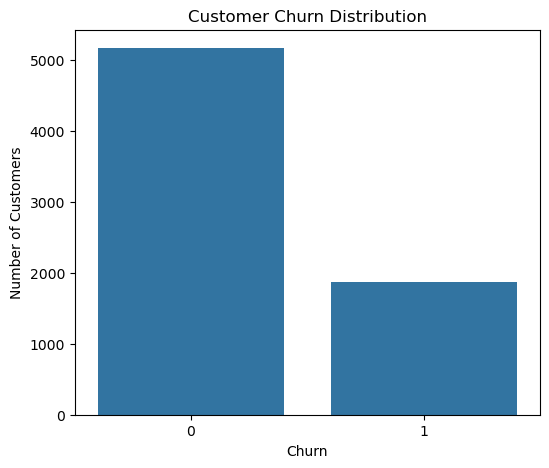

In [63]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [64]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## Churn by Gender

The relationship between customer gender and churn is analyzed to determine whether churn behavior differs between male and female customers.

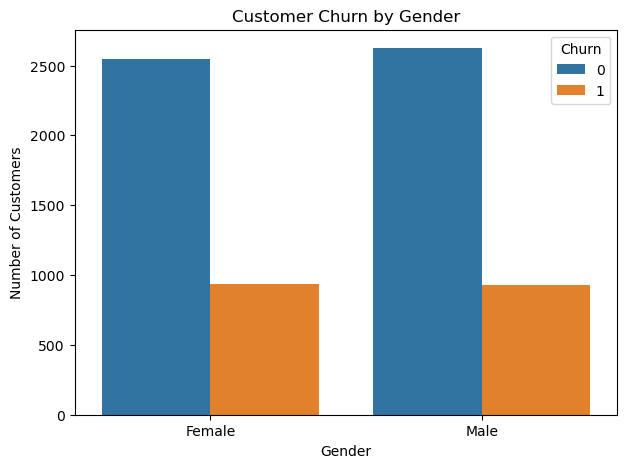

In [65]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

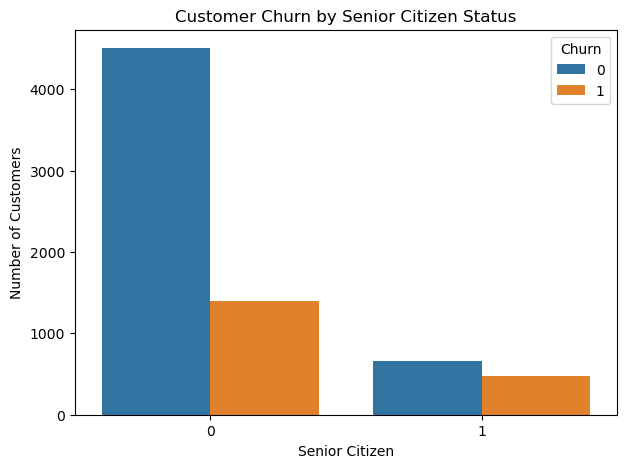

In [66]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

## Churn by Senior Citizen Status

The relationship between senior citizen status and customer churn was analyzed.

The graph shows that the number of non-senior customers is much higher than the number of senior citizen customers. Among both groups, there are more customers who did not churn than customers who churned.

However, senior citizens appear to have a higher proportion of churn compared with non-senior customers. Therefore, senior citizen status may be a useful feature for predicting customer churn.

In [67]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn.round(2))

Churn              0      1
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


### Observation

The analysis shows a noticeable difference in churn behavior based on senior citizen status.

Among non-senior citizens, 23.61% of customers churned, while 76.39% did not churn.

Among senior citizens, 41.68% of customers churned, while 58.32% did not churn.

Therefore, senior citizens have a higher churn rate than non-senior citizens in this dataset. Senior citizen status may therefore be an important feature for predicting customer churn.

## Churn by Partner

The relationship between a customer's partner status and churn is analyzed to determine whether customers with and without partners show different churn behavior.

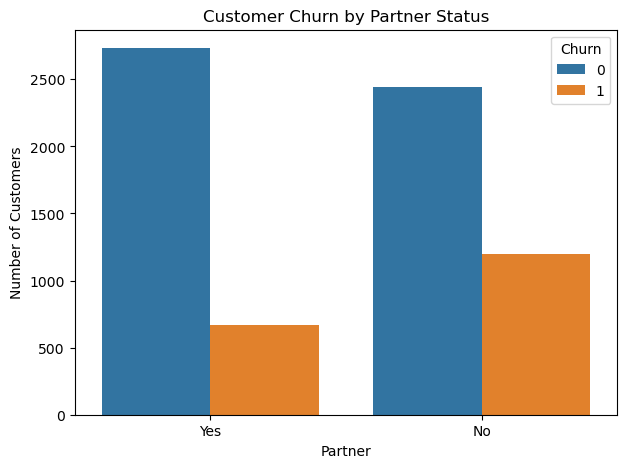

In [103]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Partner",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

In [69]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn.round(2))

Churn        0      1
Partner              
No       67.04  32.96
Yes      80.34  19.66


### Observation

The analysis shows that partner status is related to customer churn.

Among customers without a partner, 32.96% churned, while 67.04% did not churn.

Among customers with a partner, only 19.66% churned, while 80.34% did not churn.

Therefore, customers without a partner have a higher churn rate than customers with a partner. Partner status may be a useful feature for predicting customer churn.

## Churn by Dependents

The relationship between customer dependents and churn is analyzed to determine whether customers with and without dependents have different churn behavior.

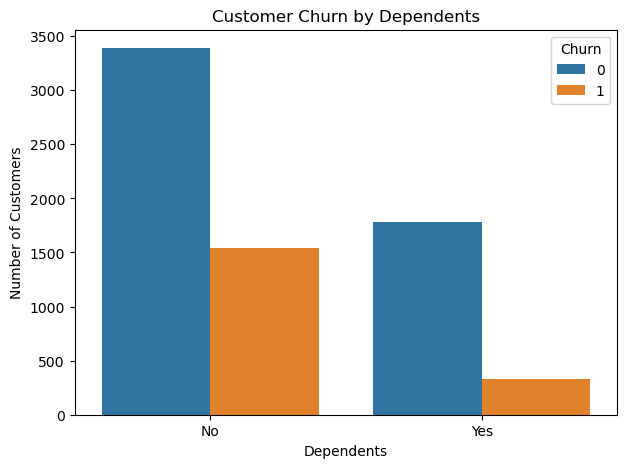

In [70]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Dependents",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

In [71]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print(dependents_churn.round(2))

Churn           0      1
Dependents              
No          68.72  31.28
Yes         84.55  15.45


### Observation

The analysis shows a clear difference in churn behavior based on dependent status.

Among customers without dependents, 31.28% churned, while 68.72% did not churn.

Among customers with dependents, only 15.45% churned, while 84.55% did not churn.

Therefore, customers without dependents have a higher churn rate than customers with dependents. This suggests that dependent status may be a useful feature for predicting customer churn.

## Churn by Contract Type

The relationship between contract type and customer churn is analyzed to determine whether customers with different contract durations have different churn behavior.

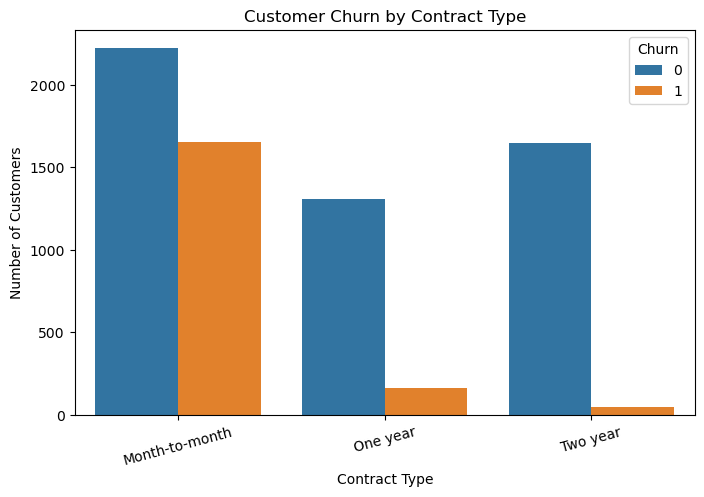

In [72]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [73]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn               0      1
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


### Observation

The analysis shows a strong relationship between contract type and customer churn.

Among customers with month-to-month contracts, 42.71% churned, while 

## Churn by Internet Service

The relationship between internet service type and customer churn is analyzed to determine whether customers using different types of internet services have different churn behavior.

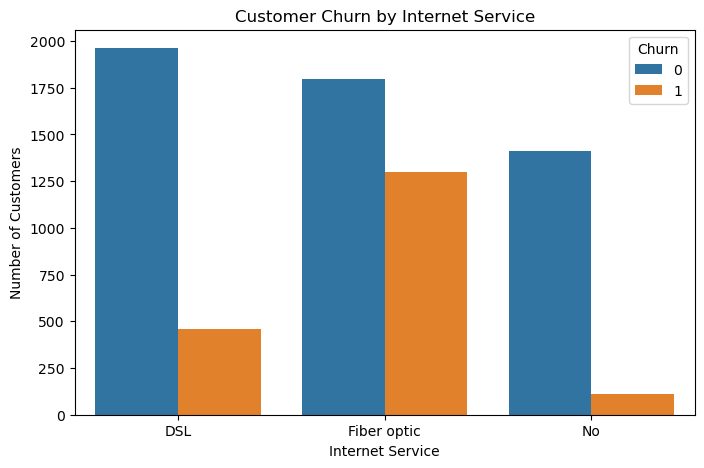

In [74]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [75]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn                0      1
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


### Observation

The analysis shows a noticeable relationship between internet service type and customer churn.

Among customers using DSL internet service, 18.96% churned, while 81.04% did not churn.

Among customers using fiber optic service, 41.89% churned, while 58.11% did not churn.

Among customers without internet service, only 7.40% churned, while 92.60% did not churn.

Therefore, customers using fiber optic internet service have the highest churn rate among the three groups, while customers without internet service have the lowest churn rate. Internet service type may therefore be an important feature for predicting customer churn.

## Churn by Payment Method

The relationship between payment method and customer churn is analyzed to determine whether customers using different payment methods show different churn behavior.

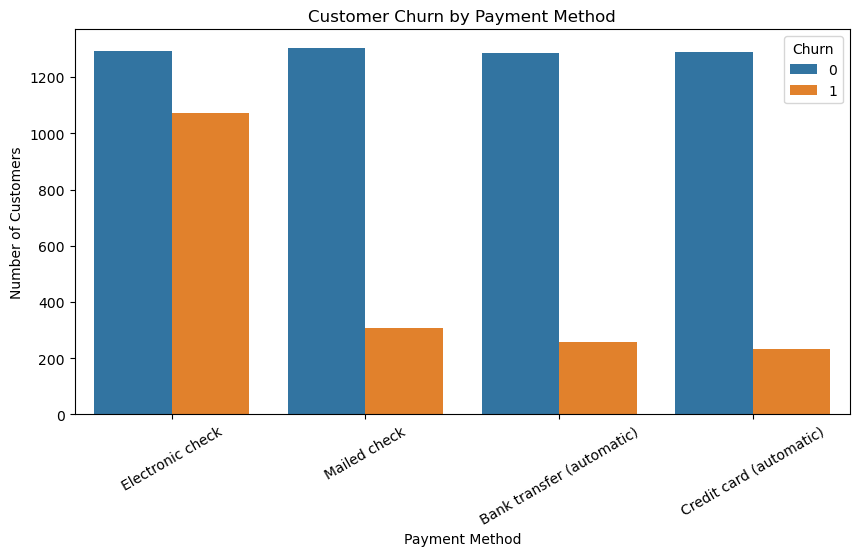

In [76]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [77]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

Churn                          0      1
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


### Observation

The analysis shows a noticeable relationship between payment method and customer churn.

Among customers using bank transfer (automatic), 16.71% churned, while 83.29% did not churn.

Among customers using credit card (automatic), 15.24% churned, while 84.76% did not churn.

Among customers using electronic check, 45.29% churned, while 54.71% did not churn.

Among customers using mailed check, 19.11% churned, while 80.89% did not churn.

Therefore, customers using electronic checks have the highest churn rate at 45.29%, while customers using automatic credit card payments have the lowest churn rate at 15.24%. Payment method may therefore be an important feature for predicting customer churn.

## Churn by Customer Tenure

Customer tenure represents the number of months a customer has remained with the company. The relationship between tenure and churn is analyzed to determine whether customers with different lengths of service have different churn behavior.

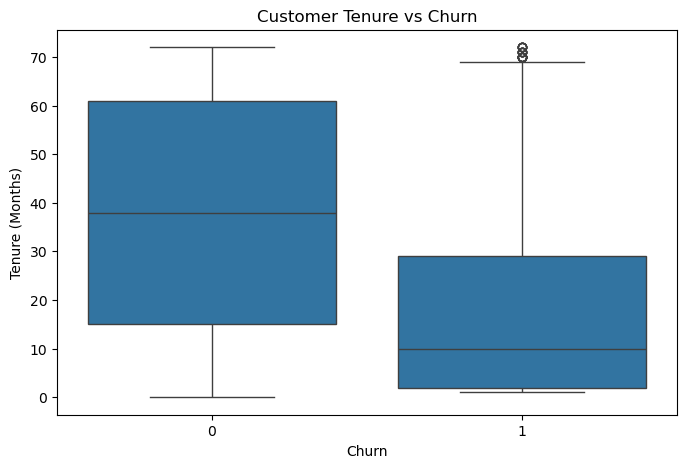

In [78]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [79]:
df.groupby("Churn")["tenure"].mean()

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

### Observation

The analysis shows a clear relationship between customer tenure and churn.

Customers who did not churn have an average tenure of approximately 37.57 months, whereas customers who churned have an average tenure of approximately 17.98 months.

The boxplot also shows that the tenure distribution for non-churned customers is generally higher than that of churned customers.

Therefore, customers with shorter tenure appear to have a higher likelihood of churning, while customers with longer tenure are more likely to remain with the company. Tenure may therefore be an important feature for predicting customer churn.

## Monthly Charges vs Churn

Monthly charges represent the amount paid by a customer each month. The relationship between monthly charges and customer churn is analyzed to determine whether customers with different monthly charges show different churn behavior.

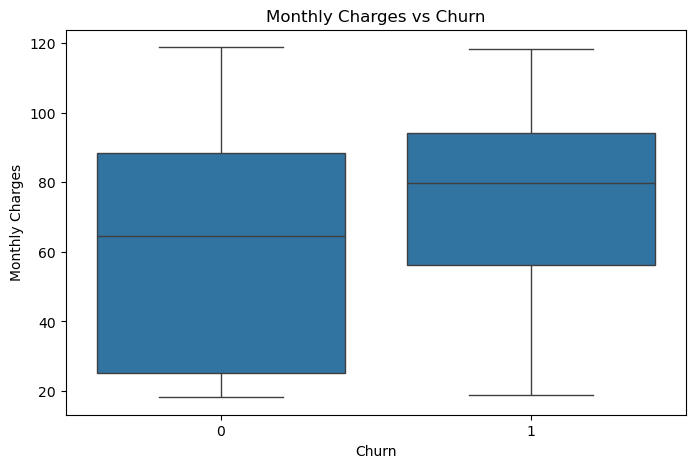

In [80]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [81]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

### Observation

The analysis shows a relationship between monthly charges and customer churn.

Customers who did not churn have an average monthly charge of approximately 61.27, whereas customers who churned have an average monthly charge of approximately 74.44.

Therefore, customers who churned generally had higher monthly charges than customers who remained with the company. Monthly charges may therefore be an important feature for predicting customer churn.

## Total Charges vs Churn

Total charges represent the total amount charged to a customer during their relationship with the company. The relationship between total charges and customer churn is analyzed to determine whether customers with different total charges show different churn behavior.

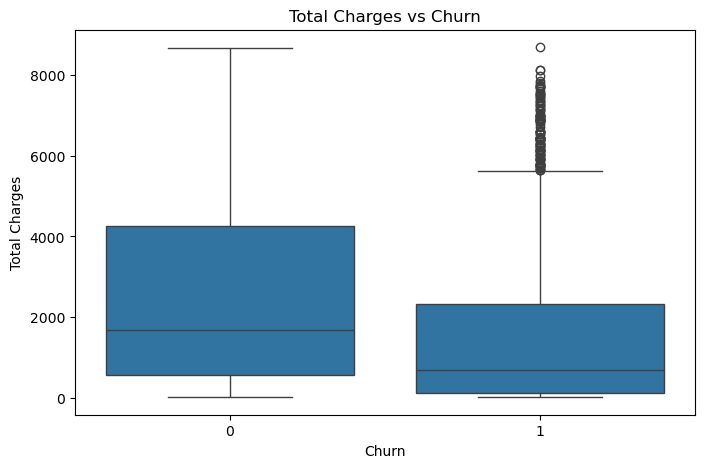

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [83]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
0    2552.882494
1    1531.796094
Name: TotalCharges, dtype: float64

### Observation

The analysis shows a difference in total charges between churned and non-churned customers.

Customers who did not churn have an average total charge of approximately 2552.88, whereas customers who churned have an average total charge of approximately 1531.80.

Therefore, customers who churned generally have lower total charges than customers who remained with the company. This may be related to their shorter tenure, as customers who leave earlier have had less time to accumulate total charges.

Total charges may therefore provide useful information for predicting customer churn.

## Data Preprocessing

After completing exploratory data analysis, the dataset is prepared for machine learning.

The preprocessing steps include:

- Removing the customer identifier because it does not provide meaningful predictive information.
- Converting `TotalCharges` into a numerical data type.
- Handling missing values.
- Separating the target variable from the input features.
- Encoding categorical variables into numerical values.
- Splitting the dataset into training and testing sets.
- Scaling features where required by the classification algorithm.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [85]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Preprocessing

The dataset has been checked for missing values and data types.

There are no missing values in the dataset, and the `TotalCharges` column has been successfully converted into a numerical data type.

The `customerID` column was removed because it is only a unique identifier and does not provide meaningful information for predicting customer churn.

The next preprocessing step is to separate the input features from the target variable and encode the categorical features into numerical values.

In [86]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [87]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


## Encoding Categorical Variables

The dataset contains categorical features that cannot be directly used by most machine learning algorithms.

One-hot encoding is used to convert categorical variables into numerical dummy variables.

The `drop_first=True` parameter removes one category from each categorical feature to reduce redundant information.

In [88]:
X = pd.get_dummies(X, drop_first=True)

In [89]:
X = X.astype(float)

In [90]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [91]:
print("Number of features after encoding:", X.shape[1])

Number of features after encoding: 30


In [92]:
X.columns.tolist()

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

## Train-Test Split

The dataset is divided into training and testing sets.

80% of the observations are used for training the machine learning models, while 20% are reserved for testing the models on unseen data.

Stratification is used to maintain a similar proportion of churned and non-churned customers in both the training and testing datasets.

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


## Feature Scaling

Feature scaling is performed before training the Logistic Regression model so that numerical features are placed on a comparable scale.

The scaler is fitted only on the training data and then applied to both training and testing data. This helps prevent data leakage from the test dataset.

In [95]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [96]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 30)
(1409, 30)


## Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict a binary outcome.

In this project, the model predicts whether a customer will churn:

- `0` → Customer does not churn
- `1` → Customer churns

Logistic Regression is used as one of the baseline classification models for the customer churn prediction problem.

In [97]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [98]:
log_pred = log_model.predict(X_test_scaled)

In [99]:
print(log_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


## Logistic Regression Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score.

These metrics provide a more complete evaluation of the classification model, especially because the churn classes are not equally distributed.

In [106]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Logistic Regression
-------------------
Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1 Score : 0.6091954022988506


In [107]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



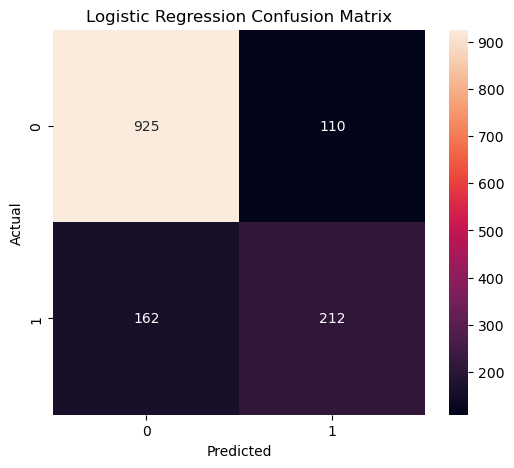

In [111]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm that makes predictions by repeatedly splitting the data based on feature values.

In this project, a Decision Tree classifier is used to predict whether a customer will churn or not. Its performance will be compared with Logistic Regression using accuracy, precision, recall, and F1-score.

In [115]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(X_test)

In [116]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree")
print("-------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree
-------------
Accuracy : 0.7416607523066004
Precision: 0.5138888888888888
Recall   : 0.4946524064171123
F1 Score : 0.5040871934604905


In [117]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



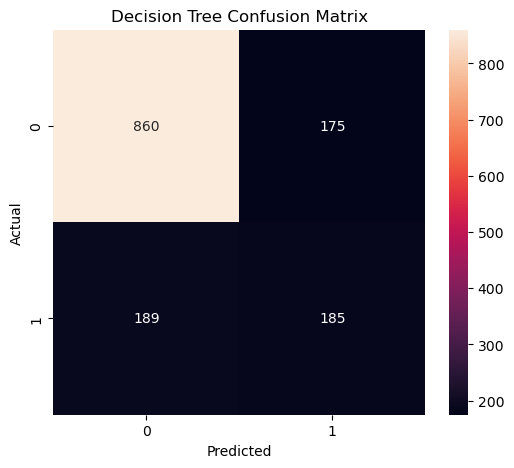

In [118]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Decision Tree model achieved an accuracy of 74.17%, which is lower than the 80.70% accuracy achieved by Logistic Regression.

The Decision Tree achieved a precision of 51.39%, a recall of 49.47%, and an F1-score of 50.41%.

Compared with Logistic Regression, the Decision Tree performed worse across all four evaluation metrics. Therefore, based on the current test results, Logistic Regression provides better predictive performance than the default Decision Tree model.

However, another classification algorithm, Random Forest, will be evaluated before selecting the final model.

## Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions.

Instead of relying on a single decision tree, Random Forest builds several trees and combines their predictions. This can improve generalization and reduce the limitations of an individual decision tree.

In this project, Random Forest is trained to predict customer churn and its performance is compared with Logistic Regression and Decision Tree.

In [119]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [120]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------
Accuracy : 0.7863733144073811
Precision: 0.6237288135593221
Recall   : 0.4919786096256685
F1 Score : 0.5500747384155455


In [121]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



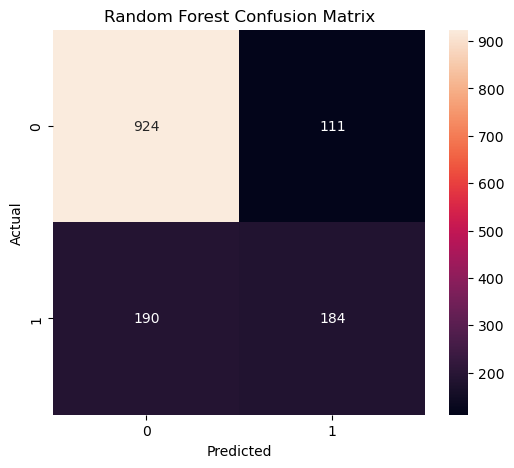

In [122]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Comparison

Three classification algorithms were trained and evaluated for customer churn prediction: Logistic Regression, Decision Tree, and Random Forest.

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.70% | 65.84% | 56.68% | 60.92% |
| Decision Tree | 74.17% | 51.39% | 49.47% | 50.41% |
| Random Forest | 78.64% | 62.37% | 49.20% | 55.01% |

Logistic Regression achieved the best performance across all four evaluation metrics. It achieved an accuracy of 80.70%, precision of 65.84%, recall of 56.68%, and F1-score of 60.92%.

Therefore, Logistic Regression is currently the best-performing model among the three evaluated models.

## Hyperparameter Tuning

Hyperparameter tuning is performed to find the best combination of model parameters that can improve classification performance.

GridSearchCV is used to test different combinations of Logistic Regression hyperparameters using cross-validation.

In [123]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [124]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [125]:
best_model = grid_search.best_estimator_

In [126]:
tuned_pred = best_model.predict(X_test_scaled)

In [127]:
tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Logistic Regression")
print("-------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned Logistic Regression
-------------------------
Accuracy : 0.8034066713981547
Precision: 0.6520376175548589
Recall   : 0.5561497326203209
F1 Score : 0.6002886002886003


In [128]:
print(classification_report(y_test, tuned_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



## Tuned Logistic Regression Results

After hyperparameter tuning using GridSearchCV, the tuned Logistic Regression model was evaluated on the test dataset.

The tuned model achieved an accuracy of 80.34%, precision of 65.20%, recall of 55.61%, and F1-score of 60.03%.

Compared with the original Logistic Regression model, the tuned model showed slightly lower performance on the test dataset. Therefore, hyperparameter tuning did not improve the test-set performance in this case.

The original Logistic Regression model remains the better-performing model based on accuracy, precision, recall, and F1-score.

In [129]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        log_precision,
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        log_recall,
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1 Score": [
        log_f1,
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.741661,0.513889,0.494652,0.504087
2,Random Forest,0.786373,0.623729,0.491979,0.550075
3,Tuned Logistic Regression,0.803407,0.652038,0.556150,0.600289


## Final Model Comparison

Four classification models were evaluated for customer churn prediction: Logistic Regression, Decision Tree, Random Forest, and Tuned Logistic Regression.

The original Logistic Regression model achieved the highest performance across accuracy, precision, recall, and F1-score.

Therefore, the original Logistic Regression model is selected as the final model for this project.

The final model achieved:

- Accuracy: 80.70%
- Precision: 65.84%
- Recall: 56.68%
- F1 Score: 60.92%

In [130]:
best_model = log_model

## Confusion Matrix of the Final Model

A confusion matrix is used to evaluate the classification performance of the final Logistic Regression model.

It shows the number of:
- True Negatives (TN): Customers correctly predicted as not churned.
- False Positives (FP): Customers incorrectly predicted as churned.
- False Negatives (FN): Customers who churned but were predicted as not churned.
- True Positives (TP): Customers correctly predicted as churned.

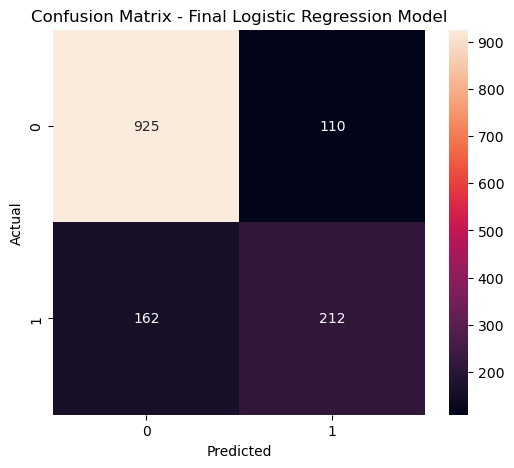

In [131]:
best_model = log_model

final_pred = best_model.predict(X_test_scaled)

cm_final = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC-AUC Evaluation

The ROC-AUC score measures the ability of the classification model to distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC score indicates better ability to distinguish between the two classes.

In [132]:
from sklearn.metrics import roc_auc_score, roc_curve

final_probability = best_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, final_probability)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8415846443979436


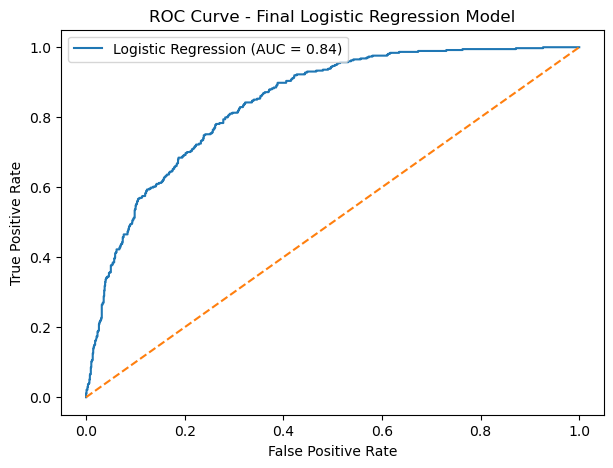

In [133]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Final Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### ROC-AUC Observation

The ROC-AUC score indicates how well the final Logistic Regression model distinguishes between customers who churn and customers who do not churn.

A higher AUC indicates better classification ability across different probability thresholds.

## New Customer Prediction

The final Logistic Regression model is used to predict whether a new customer is likely to churn.

The new customer's data must contain the same features used during model training. The categorical variables are encoded using the same one-hot encoding scheme, and the resulting features are scaled using the StandardScaler fitted on the training data.

The model then predicts whether the customer is likely to churn or remain with the company.

In [134]:
new_customer = X_test.iloc[[0]]

In [135]:
print(new_customer)

     SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
437            0.0    72.0          114.05        8468.2          1.0   

     Partner_Yes  Dependents_Yes  PhoneService_Yes  \
437          1.0             1.0               1.0   

     MultipleLines_No phone service  MultipleLines_Yes  ...  \
437                             0.0                1.0  ...   

     StreamingTV_No internet service  StreamingTV_Yes  \
437                              0.0              1.0   

     StreamingMovies_No internet service  StreamingMovies_Yes  \
437                                  0.0                  1.0   

     Contract_One year  Contract_Two year  PaperlessBilling_Yes  \
437                0.0                1.0                   1.0   

     PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
437                                    1.0                             0.0   

     PaymentMethod_Mailed check  
437                         0.0  

[1 rows x 

In [136]:
new_customer_scaled = scaler.transform(new_customer)

In [137]:
new_customer_prediction = best_model.predict(new_customer_scaled)

print("Prediction:", new_customer_prediction)

Prediction: [0]


In [138]:
if new_customer_prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

The customer is likely to stay.


In [139]:
new_customer_probability = best_model.predict_proba(
    new_customer_scaled
)[0][1]

print(
    f"Probability of Churn: {new_customer_probability:.2%}"
)

Probability of Churn: 4.44%


### Prediction Result

The final Logistic Regression model was used to predict the churn status of a new customer.

The model predicts whether the customer is likely to churn or remain with the company. The predicted churn probability provides an indication of the model's confidence in the churn prediction.

## Conclusion

This project focused on predicting customer churn using machine learning classification techniques.

Exploratory data analysis revealed several factors associated with customer churn, including contract type, internet service, payment method, tenure, monthly charges, senior citizen status, partner status, and dependent status.

Three classification algorithms were initially evaluated: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression achieved the best overall performance, with an accuracy of 80.70%, precision of 65.84%, recall of 56.68%, and F1-score of 60.92%.

Hyperparameter tuning was also performed using GridSearchCV. However, the tuned Logistic Regression model did not improve the test-set performance compared with the original Logistic Regression model.

Therefore, the original Logistic Regression model was selected as the final model for customer churn prediction.